**Chapter 13 - What Are the Chances?**

**<u>Subjective or Personal Probability</u>**

In everyday speech, when we express a degree of uncertainty without basing it on long-run relative frequencies or mathematical models, we are stating **subjective** or **personal probabilities**.

Personal probabilities don’t display the kind of consistency that we will need probabilities to have, so we’ll stick with formally defined probabilities.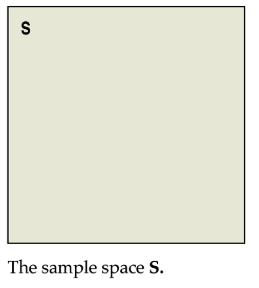

**<u>Formal Probability</u>**

1.  Two requirements for a probability:

- A probability is a number between 0 and 1.

- For any event A, 0 ≤ P(A) ≤ 1.

2.  Probability Assignment Rule: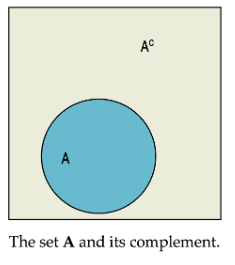

- The probability of the set of all possible outcomes of a trial must be 1.

- P(S) = 1 (S represents the set of all possible outcomes.)

3.  **Complement Rule:**

- The set of outcomes that are not in the event A is called the complement of A, denoted A<sup>C</sup>.

- The probability of an event occurring is 1 minus the probability that it doesn’t occur:

> P(A) = 1 – P(A<sup>C</sup>)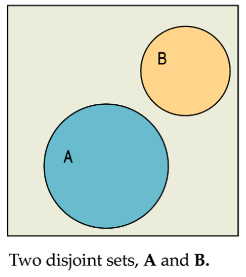

4.  **Addition Rule:**

- Events that have no outcomes in common (and, thus, cannot occur together) are called **disjoint** (or **mutually exclusive**).

- For two disjoint events A and B, the probability that one or the other occurs is the sum of the probabilities of the two events.

- $P(A \cup B) = P(A) + \ P(B)$, provided that A and B are disjoint.

5.  **Multiplication Rule:**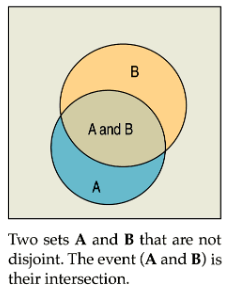

- For two independent events A and B, the probability that both A and B occur is the product of the probabilities of the two events.

- $P(A \cap B) = P(A)\ x\ P(B)$, provided that A and B are independent.

- Two independent events A and B are not disjoint, provided the two events have probabilities greater than zero:

- Many Statistics methods require an **Independence Assumption**, but assuming independence doesn’t make it true.

- Always <u>Think</u> about whether that assumption is reasonable before using the Multiplication Rule.

**<u>Formal Probability - Notation</u>**

Notation alert:

- In this course we use the notation $P(A \cap B)$ and $P(A \cup B)$.

- In other situations, you might see the following:

  - P(A or B) instead of $P(A \cup B)$

  - P(A and B) instead of $P(A \cap B)$


### Interactive Experiment: The Sample Space of Dice

When we roll **one** die, every number (1-6) is equally likely (1/6).
But when we roll **two** dice and add them up, the sums are **NOT equally likely**.

**Explore:**
*   Why is **7** the most common number?
*   Why are **2** ("Snake Eyes") and **12** ("Boxcars") so rare?
*   Increase the number of rolls to see the "pyramid" shape of the probability distribution emerge.


In [ ]:
# @title Click 'Play' to Run Code

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

def dice_sim(n_rolls=100):
    # Simulate rolling two dice
    die1 = np.random.randint(1, 7, size=n_rolls)
    die2 = np.random.randint(1, 7, size=n_rolls)
    sums = die1 + die2
    
    # Analyze Frequency
    values, counts = np.unique(sums, return_counts=True)
    freqs = counts / n_rolls
    
    # Theoretical Probabilities
    # Sums: 2(1/36), 3(2/36), 4(3/36), 5(4/36), 6(5/36), 7(6/36), ...
    theoretical_probs = {
        2: 1/36, 3: 2/36, 4: 3/36, 5: 4/36, 6: 5/36, 
        7: 6/36, 8: 5/36, 9: 4/36, 10: 3/36, 11: 2/36, 12: 1/36
    }
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Bar Chart
    possible_sums = np.arange(2, 13)
    theory_vals = [theoretical_probs[s] for s in possible_sums]
    
    plt.bar(possible_sums - 0.2, theory_vals, width=0.4, label='Theoretical Probability', color='gray', alpha=0.6)
    plt.bar(values + 0.2, freqs, width=0.4, label=f'Simulated (n={n_rolls})', color='blue', alpha=0.8)
    
    plt.xticks(possible_sums)
    plt.xlabel('Sum of Two Dice')
    plt.ylabel('Probability')
    plt.title(f"Rolling Two Dice: Why is 7 Lucky?")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

display(widgets.interactive(dice_sim, 
                            n_rolls=widgets.IntSlider(value=100, min=10, max=5000, step=10, description='Rolls:')))


**<u>Putting the Rules to Work</u>**

- In most situations where we want to find a probability, we’ll use the rules in combination.

- A good thing to remember is that it can be easier to work with the complement of the event we’re really interested in.

**<u>What Can Go Wrong?</u>**

- Beware of probabilities that don’t add up to 1.

  - To be a legitimate probability distribution, the sum of the probabilities for all possible outcomes must total 1.

- Don’t add probabilities of events if they’re not disjoint.

  - Events must be disjoint to use the Addition Rule.

- Don’t multiply probabilities of events if they’re not independent.

  - The multiplication of probabilities of events that are not independent is one of the most common errors people make in dealing with probabilities.

- Don’t confuse disjoint and independent—disjoint events *can’t* be independent.

**THINK SHOW TELL**

**<span class="mark">Examples:</span>**

<span class="mark">We opened the last chapter by looking at the structural monitoring sensor on a bridge pier, observing that when we check the sensor reading, the indicator is green (safe) about 35% of the time.</span>

<span class="mark">If P(green/safe) = 0.35, what's the probability the indicator is NOT green?</span>

<span class="mark">P(not green) = 1 − P(green) = 1 − 0.35 = 0.65</span>

<span class="mark">If P(green/safe) = 0.35 and P(yellow/caution) = 0.04, what is P(red/alert)?</span>

<span class="mark">P(green) + P(yellow) + P(red) = 1, so P(red) = 1 − 0.35 − 0.04 = 0.61.</span>

- <span class="mark">A correctly designed reinforced concrete beam has a much better than 50-50 chance of safely carrying its design load.</span>


### Interactive Experiment: The Structural Monitoring Model

Probability describes the long-run frequency of an event. A legitimate probability model must satisfy two rules:
1. Any probability is a number between 0 and 1.
2. The sum of logical outcomes must equal 1.

**Scenario:** A structural health monitoring sensor on a bridge pier has three states:
*   🟢 **Safe** (P = ?)
*   🟡 **Caution** (P = ?)
*   🔴 **Alert** (P = 1 − P(safe) − P(caution))

Use the sliders below to set P(Safe) and P(Caution) and observe the resulting P(Alert) and how it behaves over many sensor readings.


In [ ]:
# @title Click 'Play' to Run Code
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output

def run_sensor_simulation(p_safe, p_caution, n_readings):
    # Calculate P(Alert) ensuring sum = 1
    p_alert = round(1.0 - p_safe - p_caution, 2)
    
    if p_alert < 0:
        print("Error: P(Safe) + P(Caution) cannot exceed 1.0!")
        return
    
    # Simulate sensor readings
    outcomes = np.random.choice(['Safe', 'Caution', 'Alert'], size=n_readings, p=[p_safe, p_caution, p_alert])
    
    counts = {'Safe': 0, 'Caution': 0, 'Alert': 0}
    for o in outcomes:
        counts[o] += 1
    
    # Calculate observed frequencies
    freqs = {k: v/n_readings for k, v in counts.items()}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Theoretical vs Observed
    categories = ['Safe', 'Caution', 'Alert']
    theoretical = [p_safe, p_caution, p_alert]
    observed = [freqs[c] for c in categories]
    colors = ['#4CAF50', '#FFC107', '#F44336']
    
    x = np.arange(len(categories))
    width = 0.35
    axes[0].bar(x - width/2, theoretical, width, label='Theoretical', color=colors, alpha=0.5, edgecolor='black')
    axes[0].bar(x + width/2, observed, width, label=f'Observed (n={n_readings})', color=colors, edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'🟢 {categories[0]}', f'🟡 {categories[1]}', f'🔴 {categories[2]}'])
    axes[0].set_ylabel('Probability / Frequency')
    axes[0].set_title('Theoretical vs. Observed Sensor Readings')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    
    # Right: Cumulative frequency convergence
    cumulative = np.cumsum([1 if o == 'Safe' else 0 for o in outcomes]) / np.arange(1, n_readings+1)
    axes[1].plot(cumulative, color='green', alpha=0.7)
    axes[1].axhline(p_safe, color='black', linestyle='--', label=f'True P(Safe) = {p_safe}')
    axes[1].set_xlabel('Number of Sensor Readings')
    axes[1].set_ylabel('Cumulative Proportion of Safe Readings')
    axes[1].set_title('Law of Large Numbers: Convergence to True Probability')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Theoretical: P(Safe)={p_safe}, P(Caution)={p_caution}, P(Alert)={p_alert}")
    print(f"Observed:    P(Safe)={freqs['Safe']:.3f}, P(Caution)={freqs['Caution']:.3f}, P(Alert)={freqs['Alert']:.3f}")

style = {'description_width': 'initial'}
display(widgets.interactive(run_sensor_simulation,
    p_safe=widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.01, description='P(Safe):', style=style),
    p_caution=widgets.FloatSlider(value=0.04, min=0.0, max=0.5, step=0.01, description='P(Caution):', style=style),
    n_readings=widgets.IntSlider(value=100, min=10, max=5000, step=10, description='# Readings:', style=style)))
